In [1]:
!pip install scikit-learn xgboost shap joblib matplotlib seaborn

Access is denied.


In [1]:
import os
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

SEED = 42
np.random.seed(SEED)

DATA_PATH = "../data/processed/merged_features.csv"   
MODEL_DIR = "../models"
os.makedirs(MODEL_DIR, exist_ok=True)

print("Ready. Data path:", DATA_PATH)


Ready. Data path: ../data/processed/merged_features.csv


In [2]:
# Toggle this to work in a light "dev" mode vs full dataset
USE_DEV_SAMPLE = True  # set to False when you want full training

# Default full dataset
FULL_DATA_PATH = "../data/processed/merged_features.csv"
DEV_SAMPLE_PATH = "../models/df_sample_5k.csv"  # small subset for fast/local runs

DATA_PATH = DEV_SAMPLE_PATH if USE_DEV_SAMPLE else FULL_DATA_PATH
print("Using dev sample:" if USE_DEV_SAMPLE else "Using full dataset:", DATA_PATH)


Using dev sample: ../models/df_sample_5k.csv


In [3]:
# Loading and inspecting data
df = pd.read_csv(DATA_PATH, parse_dates=["date", "intervention_start", "intervention_end", "week_start"], low_memory=False)
print("Shape:", df.shape)
display(df.head())
print("\nColumns:", list(df.columns))
print("\nBasic stats for key columns:")
display(df[["mood_score","stress_level","health_twin_index","sleep_hours"]].describe())


Shape: (5000, 103)


C:\Users\bhanu\AppData\Local\Temp\ipykernel_21952\365258458.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(DATA_PATH, parse_dates=["date", "intervention_start", "intervention_end", "week_start"], low_memory=False)
C:\Users\bhanu\AppData\Local\Temp\ipykernel_21952\365258458.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(DATA_PATH, parse_dates=["date", "intervention_start", "intervention_end", "week_start"], low_memory=False)


,user_id,date,week_start,workday,profession,work_mode,chronotype,age,sex,height_cm,...,mood_lag1,mood_lag2,mood_roll_3,stress_lag1,stress_roll_3,energy_lag1,energy_roll_3,user_id_te_mood_next_day,user_id_te_stress_next_day,user_id_te_energy_next_day
0,913,2025-07-25,2025-07-21,1,teacher,onsite,evening,57,male,171,...,6,8.0,6.666667,1,3.000000,7,6.000000,6.104110,4.291781,5.728767
1,843,2025-01-12,2025-01-06,0,operations,onsite,evening,24,female,159,...,8,7.0,6.666667,4,4.000000,9,8.333333,6.167123,4.091781,5.787671
2,269,2024-05-29,2024-05-27,1,operations,onsite,evening,50,male,162,...,4,4.0,4.000000,6,5.000000,6,6.000000,6.209589,4.182192,5.889041
3,136,2025-10-12,2025-10-06,0,operations,onsite,intermediate,37,male,182,...,8,5.0,6.333333,4,4.333333,5,5.666667,6.223288,4.165753,5.965753
4,816,2025-08-18,2025-08-18,1,teacher,onsite,intermediate,60,female,174,...,10,6.0,8.333333,7,5.666667,7,6.333333,6.130137,4.302740,5.727397



Columns: ['user_id', 'date', 'week_start', 'workday', 'profession', 'work_mode', 'chronotype', 'age', 'sex', 'height_cm', 'mental_health_history', 'exercise_habit', 'caffeine_sensitivity', 'baseline_bmi', 'sleep_hours', 'sleep_quality', 'work_hours', 'meetings_count', 'tasks_completed', 'emails_received', 'commute_minutes', 'exercise_minutes', 'steps_count', 'caffeine_mg', 'alcohol_units', 'screen_time_hours', 'social_interactions', 'outdoor_time_minutes', 'diet_quality', 'calories_intake', 'stress_level', 'mood_score', 'energy_level', 'focus_score', 'work_pressure', 'weather_mood_impact', 'weight_kg', 'job_satisfaction_x', 'perceived_stress_scale_x', 'anxiety_score_x', 'depression_score_x', 'sleep_debt_hours_x', 'avg_weight_kg_week', 'workouts_count_x', 'cheat_meals_count_x', 'has_intervention', 'intervention_diet_coaching', 'intervention_exercise_plan', 'intervention_meditation', 'intervention_sick_leave', 'intervention_therapy', 'intervention_vacation', 'intervention_workload_cap',

,mood_score,stress_level,health_twin_index,sleep_hours
count,5000.000000,5000.000000,5000.000000,5000.000000
mean,6.175600,4.237200,58.017851,7.203856
std,1.476753,1.180345,8.641531,0.873377
min,1.000000,1.000000,27.881015,4.130000
25%,5.000000,3.000000,52.255845,6.620000
50%,6.000000,4.000000,58.478669,7.190000
75%,7.000000,5.000000,64.058661,7.780000
max,10.000000,9.000000,87.055789,10.320000


In [4]:
# Preparing X, y (predicting mood_score)
# Dropping columns not to be input features (IDs, text meta, direct targets)
drop_cols = [
    "date", "user_id", "intervention_start", "intervention_end",
    "intervention_type", "intervention_intensity", "week_start"
]

# Make sure target exists
target = "mood_score"
assert target in df.columns, f"{target} not found in df columns"

# Build X, y
X = df.drop(columns=drop_cols + [target, "health_twin_index", "stress_level"], errors="ignore")
y = df[target].fillna(method="ffill").fillna(method="bfill").fillna(df[target].mean())

# Quick check: numeric-only features for baseline models
X_num = X.select_dtypes(include=[np.number]).copy()

print("Feature matrix (numeric) shape:", X_num.shape)
print("Example features:", X_num.columns[:15])


Feature matrix (numeric) shape: (5000, 85)
Example features: Index(['workday', 'age', 'height_cm', 'baseline_bmi', 'sleep_hours',
       'sleep_quality', 'work_hours', 'meetings_count', 'tasks_completed',
       'emails_received', 'commute_minutes', 'exercise_minutes', 'steps_count',
       'caffeine_mg', 'alcohol_units'],
      dtype='object')


C:\Users\bhanu\AppData\Local\Temp\ipykernel_21952\3592806938.py:14: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  y = df[target].fillna(method="ffill").fillna(method="bfill").fillna(df[target].mean())


In [5]:
# Train test split and scaling
X_train, X_test, y_train, y_test = train_test_split(X_num, y, test_size=0.2, random_state=SEED)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Train shape: (4000, 85) Test shape: (1000, 85)


In [6]:
# Baseline: Linear Regression baseline
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print(f"Linear Regression — MSE: {mse_lr:.4f}, R²: {r2_lr:.4f}")

ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [22]:
# Random Forest
rf = RandomForestRegressor(n_estimators=200, random_state=SEED, n_jobs=-1)
rf.fit(X_train, y_train)   # using unscaled numeric features is OK for RF
y_pred_rf = rf.predict(X_test)

mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest — MSE: {mse_rf:.4f}, R²: {r2_rf:.4f}")


Random Forest — MSE: 1.2757, R²: 0.4058


C:\Users\bhanu\AppData\Local\Temp\ipykernel_22456\3535379764.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top.values, y=top.index, palette="viridis")


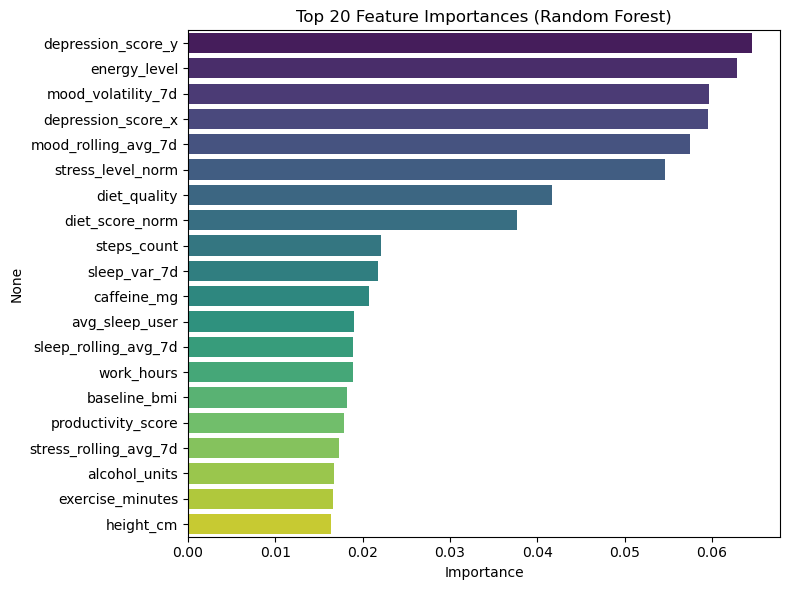

depression_score_y       0.064579
energy_level             0.062917
mood_volatility_7d       0.059652
depression_score_x       0.059574
mood_rolling_avg_7d      0.057484
stress_level_norm        0.054607
diet_quality             0.041700
diet_score_norm          0.037639
steps_count              0.022066
sleep_var_7d             0.021815
caffeine_mg              0.020699
avg_sleep_user           0.018993
sleep_rolling_avg_7d     0.018959
work_hours               0.018936
baseline_bmi             0.018260
productivity_score       0.017836
stress_rolling_avg_7d    0.017273
alcohol_units            0.016694
exercise_minutes         0.016592
height_cm                0.016427
dtype: float64


In [23]:
# Feature importance
feat_imp = pd.Series(rf.feature_importances_, index=X_num.columns).sort_values(ascending=False)
top = feat_imp.head(20)

plt.figure(figsize=(8,6))
sns.barplot(x=top.values, y=top.index, palette="viridis")
plt.title("Top 20 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

# print top features
print(top)

In [24]:
# Next-day mood target and retrain
df_td = df.copy()
df_td = df_td.sort_values(["user_id","date"])
df_td["mood_next_day"] = df_td.groupby("user_id")["mood_score"].shift(-1)

# Dropping rows where next-day is NA
df_td = df_td.dropna(subset=["mood_next_day"])

# Rebuilding numeric features and X,y for next-day prediction
X_td = df_td.drop(columns=drop_cols + ["mood_score", "mood_next_day", "health_twin_index", "stress_level"], errors="ignore")
X_td_num = X_td.select_dtypes(include=[np.number]).copy()
y_td = df_td["mood_next_day"]

Xtr, Xte, ytr, yte = train_test_split(X_td_num, y_td, test_size=0.2, random_state=SEED)
rf_next = RandomForestRegressor(n_estimators=200, random_state=SEED, n_jobs=-1)
rf_next.fit(Xtr, ytr)
y_pred_next = rf_next.predict(Xte)

print("Next-day Random Forest — MSE:", mean_squared_error(yte, y_pred_next), "R2:", r2_score(yte, y_pred_next))


MemoryError: could not allocate 33554432 bytes